In [24]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [25]:
para = '''
The world looked ordinary, but nothing was truly real. Every mountain, river, city, and
star was part of a giant virtual reality created by an unknown civilization. People lived
their lives without questioning the strange glitches that appeared from time to time.
 Sometimes the sky flickered, clocks stopped for a second, or memories changed overnight.
 Scientists searched for logical explanations, but none could explain these impossible events.
One curious student named Aria refused to ignore the mysteries. She noticed repeating patterns
 in nature and discovered hidden lines of code embedded within ancient monuments. The more she
 investigated, the more the world began to respond to her actions. Doors appeared where walls once
  stood, and impossible landscapes unfolded before her eyes.
One night, Aria found a glowing portal beneath an abandoned observatory. As she stepped through,
 she saw millions of worlds running simultaneously, each with different histories and futures.
 A calm voice greeted her and said, "Your reality is only one simulation among countless others.
 Every choice creates another version of the world."
Aria realized that fear was meaningless inside a simulation. Instead of escaping, she returned
 home determined to improve her world. Whether it was virtual or real no longer mattered. Kindness,
  courage, and curiosity still gave life its purpose. From that day forward, she inspired others to question
  reality while making their own world a better place.
'''
print(para)


The world looked ordinary, but nothing was truly real. Every mountain, river, city, and 
star was part of a giant virtual reality created by an unknown civilization. People lived 
their lives without questioning the strange glitches that appeared from time to time.
 Sometimes the sky flickered, clocks stopped for a second, or memories changed overnight. 
 Scientists searched for logical explanations, but none could explain these impossible events.
One curious student named Aria refused to ignore the mysteries. She noticed repeating patterns
 in nature and discovered hidden lines of code embedded within ancient monuments. The more she 
 investigated, the more the world began to respond to her actions. Doors appeared where walls once
  stood, and impossible landscapes unfolded before her eyes.
One night, Aria found a glowing portal beneath an abandoned observatory. As she stepped through,
 she saw millions of worlds running simultaneously, each with different histories and futures. 
 A 

Tokenization & Sequence Creation

In [26]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([para])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in para.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 165
X shape: (211, 16)
y shape: (211,)


Model 1: Vanilla RNN

In [27]:
rnn_model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


 Model 2: LSTM

In [28]:
lstm_model = Sequential([Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


Model 3: GRU

In [29]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


training loss

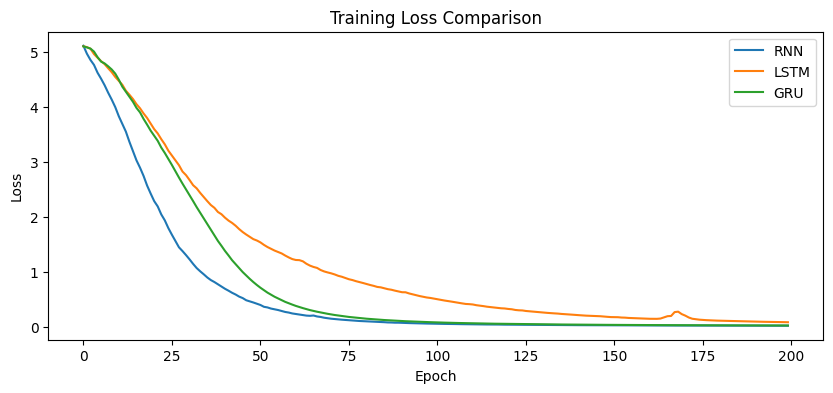

In [30]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

Text Generation Function

In [31]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [32]:
print("RNN :", generate_text(rnn_model, "Aria found out", 10))
print("LSTM:", generate_text(lstm_model,"Aria found out", 10))
print("GRU :", generate_text(gru_model, "Aria found out", 10))

RNN : Aria found out that fear was meaningless inside a simulation instead of escaping
LSTM: Aria found out that fear was meaningless a simulation instead instead of escaping
GRU : Aria found out the world began to respond to her actions doors appeared
